<small>This code was made by [Riccardo Campi](https://scholar.google.com/citations?user=JWSoz7EAAAAJ&hl=it), Politecnico di Milano, Data Science Lab.</small>
<br><small>Thanks to [UBC Library Research Computing](https://github.com/ubc-library-rc/ml-classification-clustering/) for inspiring this notebook.</small>

### 5.3 Clustering

In this section, we will focus on unsupervised learning, specifically clustering, where the goal is to group similar data points together based on their features without any predefined labels.
<br>We will use the `bank marketing dataset`, which contains information about various features of bank customers and their corresponding responses to a marketing campaign, to demonstrate clustering techniques.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [11]:
# Load the bank marketing dataset
bank_marketing = pd.read_csv('./datasets/marketing-data.csv')

# Print the first few rows of the dataset
bank_marketing.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,is_success
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [12]:
# Print information about the dataset
bank_marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   age         45211 non-null  int64 
 1   job         45211 non-null  object
 2   marital     45211 non-null  object
 3   education   45211 non-null  object
 4   default     45211 non-null  object
 5   balance     45211 non-null  int64 
 6   housing     45211 non-null  object
 7   loan        45211 non-null  object
 8   contact     45211 non-null  object
 9   day         45211 non-null  int64 
 10  month       45211 non-null  object
 11  duration    45211 non-null  int64 
 12  campaign    45211 non-null  int64 
 13  pdays       45211 non-null  int64 
 14  previous    45211 non-null  int64 
 15  poutcome    45211 non-null  object
 16  is_success  45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


#### 5.3.1 Data Pre-processing

Before applying clustering algorithms, we need to preprocess the data to ensure that it is in a suitable format for clustering.
<br>In this case, we will focus on encoding categorical variables.

In [13]:
# Select all the categorical features and the target variable
X_bank = bank_marketing[['job', 'education',  'default', 'balance', 'housing', 'loan']]

# Isolate all the categorical features
cat_feat = ['job', 'education', 'default', 'housing', 'loan']
X_cat = X_bank[cat_feat]

# Print the first few rows of the categorical features
X_cat.head()

,job,education,default,housing,loan
0,management,tertiary,no,yes,no
1,technician,secondary,no,yes,no
2,entrepreneur,secondary,no,yes,yes
3,blue-collar,unknown,no,yes,no
4,unknown,unknown,no,no,no


**One-hot encoding** is a common technique used to convert categorical variables into a format that can be provided to machine learning algorithms.
<br>It creates new binary columns for each category in the original categorical variable, where each column indicates the presence of a specific category in the original variable.
<br>This allows us to represent categorical data in a numerical format that can be used for clustering algorithms.

In [14]:
from sklearn.preprocessing import OneHotEncoder

# create and instance of OneHotEncoder
enc = OneHotEncoder()

# apply fit_transform on dataframe with categorical features only
X_cat_ohe = enc.fit_transform(X_cat)

# convert result into numpy array
X_cat_ohe = X_cat_ohe.toarray()

# convert result into pandas dataframe
X_cat_ohe = pd.DataFrame(X_cat_ohe)

# Rename columns
X_cat_ohe.columns = enc.get_feature_names_out(cat_feat)

X_bank.drop(cat_feat, axis=1, inplace=True)
X_bank = pd.concat([X_bank, X_cat_ohe], axis=1)

# Print the first few rows of the dataframe with one-hot encoded features
X_bank.head() 

/tmp/ipykernel_3183358/3453389101.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_bank.drop(cat_feat, axis=1, inplace=True)


,balance,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,education_primary,education_secondary,education_tertiary,education_unknown,default_no,default_yes,housing_no,housing_yes,loan_no,loan_yes
0,2143,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1,29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
3,1506,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
4,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0


> Note how we are keeping the "unknown" category in the one-hot encoding, as it can provide useful information for clustering, especially if it represents a significant portion of the data.

#### 5.3.2 Clustering with K-Means

**K-Means** is a popular clustering algorithm that partitions the data into K clusters based on the features of the data points.
<br>It works by initializing K centroids randomly, assigning each data point to the nearest centroid to form clusters, and then updating the centroids by calculating the mean of the data points in each cluster.
<br>This process is repeated iteratively until the centroids do not change significantly, indicating that the clusters have stabilized.

In [15]:
from sklearn.cluster import KMeans

# Create an instance of KMeans with 2 clusters and fit the model to the data
k_means = KMeans(n_clusters=2, init='random', random_state=42)
k_means.fit(X_bank)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'random'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [16]:
 # Print the cluster centers
print(k_means.cluster_centers_)

[[8.96550579e+02 1.16080298e-01 2.18461965e-01 3.27103883e-02
  2.75127631e-02 2.04601631e-01 4.92272864e-02 3.43505278e-02
  9.35110536e-02 2.08367022e-02 1.68195154e-01 2.82981820e-02
  6.21404976e-03 1.52371272e-01 5.18792303e-01 2.87994641e-01
  4.08417843e-02 9.81196147e-01 1.88038532e-02 4.39257086e-01
  5.60742914e-01 8.35385433e-01 1.64614567e-01]
 [1.18516670e+04 7.59625390e-02 1.43080125e-01 3.69406868e-02
  2.54942768e-02 3.12695109e-01 6.91987513e-02 4.78668054e-02
  5.51508845e-02 1.87304891e-02 1.64412071e-01 4.05827263e-02
  9.88553590e-03 1.32674298e-01 3.87096774e-01 4.33922997e-01
  4.63059313e-02 9.99479709e-01 5.20291363e-04 5.54630593e-01
  4.45369407e-01 9.38605619e-01 6.13943809e-02]]


#### 5.3.3 Evaluating with Silhouette Score and Inertia

The **Silhouette Score** is a metric used to evaluate the quality of clusters formed by a clustering algorithm.
<br>It measures how similar an object is to its own cluster compared to other clusters.
<br>The silhouette score ranges from -1 to 1, where a score close to 1 indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters, while a score close to -1 indicates that the object is misclassified and should be assigned to a different cluster. A score around 0 indicates that the object is on the boundary of two clusters.

The **Inertia** is another metric used to evaluate the quality of clusters, which measures the sum of squared distances of samples to their closest cluster center.
<br>A lower inertia indicates that the clusters are more compact and well-defined, while a higher inertia indicates that the clusters are more dispersed and less well-defined.

In [17]:
from sklearn.metrics import silhouette_score
import os

save = False  # Set to True to save the silhouette scores and inertia values to cache

# Evaluate the clustering performance using silhouette score
if not save:
    # Load from cache if available
    silhouette = np.load('./cache/silhouette.npy')
    inertia = np.load('./cache/inertia.npy')
    krange = np.load('./cache/krange.npy')
else:
    # Compute silhouette scores
    silhouette = []
    inertia = []
    krange = range(2, 11)
    for i in krange:
        print(i)
        kmeans = KMeans(n_clusters=i, init='random', random_state=42)
        kmeans.fit(X_bank)
        sscore = round(silhouette_score(X_bank, kmeans.labels_), 2)
        silhouette.append(sscore)
        inertia.append(kmeans.inertia_)
    # Save to cache
    os.makedirs('./cache', exist_ok=True)
    np.save('./cache/silhouette.npy', silhouette)
    np.save('./cache/inertia.npy', inertia)
    np.save('./cache/krange.npy', krange)

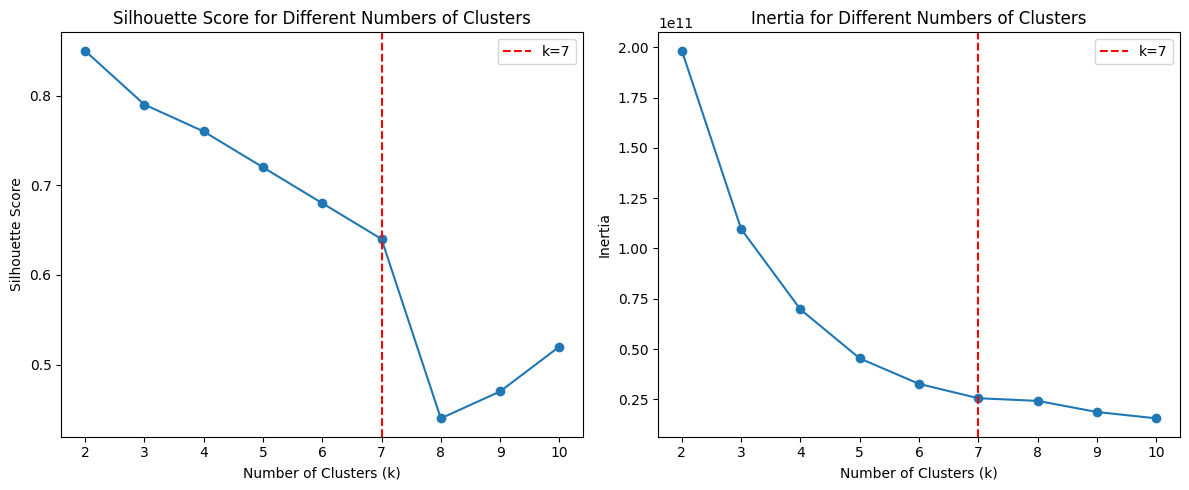

In [18]:
# Plot the silhouette scores and inertia values for different numbers of clusters
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(krange, silhouette, marker='o')
plt.title('Silhouette Score for Different Numbers of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.subplot(1, 2, 2)
plt.plot(krange, inertia, marker='o')
plt.title('Inertia for Different Numbers of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

# Put a line to indicate the optimal number of clusters based on silhouette score and inertia
best_k = 7
plt.subplot(1, 2, 1)
plt.axvline(x=best_k, color='red', linestyle='--', label='k=7')
plt.legend()
plt.subplot(1, 2, 2)
plt.axvline(x=best_k, color='red', linestyle='--', label='k=7')
plt.legend()

plt.tight_layout()
plt.show()